In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold

from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import DBSCAN

from sklearn.metrics import silhouette_score

from sklearn.manifold import TSNE

import warnings
warnings.filterwarnings("ignore")

In [ ]:
from google.colab import files

files.upload()      # selecione kaggle.json

Saving kaggle.json to kaggle (4).json


{'kaggle (4).json': b'{"username":"luanmoon","key":"1eefa35a0c2c6451f15ab3d5a7af5217"}'}

In [ ]:
!mkdir -p ~/.kaggle

!cp kaggle.json ~/.kaggle/

!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!pip install -q kaggle

In [ ]:
!kaggle datasets download \
-d ymirsky/network-attack-dataset-kitsune

Dataset URL: https://www.kaggle.com/datasets/ymirsky/network-attack-dataset-kitsune
License(s): GNU Affero General Public License 3.0
network-attack-dataset-kitsune.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
!unzip -q network-attack-dataset-kitsune.zip -d kitsune

replace kitsune/ARP MitM/ARP_MitM_dataset.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [ ]:
import os

for raiz, _, arquivos in os.walk("kitsune"):
    for arquivo in arquivos:
        print(os.path.join(raiz, arquivo))

kitsune/ARP MitM/ARP_MitM_dataset.csv
kitsune/ARP MitM/ARP_MitM_labels.csv
kitsune/ARP MitM/ARP_MitM_pcap.pcapng
kitsune/Active Wiretap/Active_Wiretap_labels.csv
kitsune/Active Wiretap/Active_Wiretap_dataset.csv
kitsune/Active Wiretap/Active_Wiretap_pcap.pcapng
kitsune/Fuzzing/Fuzzing_dataset.csv


## Experimento 1

Dataset kitsune com aprendizado não supervisionado tradicional em cenário offline.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

from sklearn.decomposition import PCA

from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import DBSCAN

from sklearn.manifold import TSNE

from sklearn.metrics import silhouette_score

In [ ]:
dataset = pd.read_csv("kitsune/ARP MitM/ARP_MitM_dataset.csv")

print(dataset.shape)

dataset.head()

(2504266, 115)


,1.000000000000000000e+00,1.294000000000000000e+03,0.000000000000000000e+00,1.000000000000000000e+00.1,1.294000000000000000e+03.1,0.000000000000000000e+00.1,1.000000000000000000e+00.2,1.294000000000000000e+03.2,0.000000000000000000e+00.2,1.000000000000000000e+00.3,...,0.000000000000000000e+00.48,0.000000000000000000e+00.49,0.000000000000000000e+00.50,1.000000000000000000e+00.24,1.294000000000000000e+03.28,0.000000000000000000e+00.51,1.294000000000000000e+03.29,0.000000000000000000e+00.52,0.000000000000000000e+00.53,0.000000000000000000e+00.54
0,1.000000,1514.0,0.000000e+00,1.000000,1514.0,0.000000e+00,1.000000,1514.0,0.000000e+00,1.000000,...,0.000000e+00,0.0,0.0,1.000000,1514.0,0.000000,1514.0,0.000000e+00,0.0,0.0
1,1.999505,1294.0,6.984919e-10,1.999703,1294.0,2.328306e-10,1.999901,1294.0,6.984919e-10,1.999990,...,0.000000e+00,0.0,0.0,1.999999,1294.0,0.000000,1294.0,0.000000e+00,0.0,0.0
2,2.998985,1294.0,9.313226e-10,2.999391,1294.0,4.656613e-10,2.999797,1294.0,6.984919e-10,2.999980,...,6.984919e-10,0.0,0.0,2.999998,1294.0,0.000015,1294.0,2.328306e-10,0.0,0.0
3,3.998061,1294.0,9.313226e-10,3.998836,1294.0,2.328306e-10,3.999612,1294.0,6.984919e-10,3.999961,...,2.328306e-10,0.0,0.0,3.999996,1294.0,0.000000,1294.0,0.000000e+00,0.0,0.0
4,4.996578,1294.0,6.984919e-10,4.997946,1294.0,4.656613e-10,4.999315,1294.0,0.000000e+00,4.999932,...,4.656613e-10,0.0,0.0,4.999993,1294.0,0.000000,1294.0,0.000000e+00,0.0,0.0


In [ ]:
from sklearn.model_selection import train_test_split

# Número de instâncias utilizadas no experimento
sample_size = 10000

# Amostragem aleatória reprodutível
X_sample, _ = train_test_split(
    dataset,
    train_size=sample_size,
    random_state=42,
    shuffle=True
)

# Substitui o dataset original pela amostra
dataset = X_sample.reset_index(drop=True)

print("Quantidade de instâncias utilizadas:", len(dataset))

Quantidade de instâncias utilizadas: 10000


In [ ]:
# Pré-processamento
dataset = dataset.fillna(0)

dataset = dataset.replace(
    [np.inf, -np.inf],
    0
)

X = dataset.copy()

In [ ]:
scaler = StandardScaler()

X = scaler.fit_transform(X)

In [ ]:
pca = PCA(
    n_components=0.95,
    random_state=42
)

X_pca = pca.fit_transform(X)

print("Dimensão original :", X.shape[1])

print("Após PCA :", X_pca.shape[1])

Dimensão original : 115
Após PCA : 17


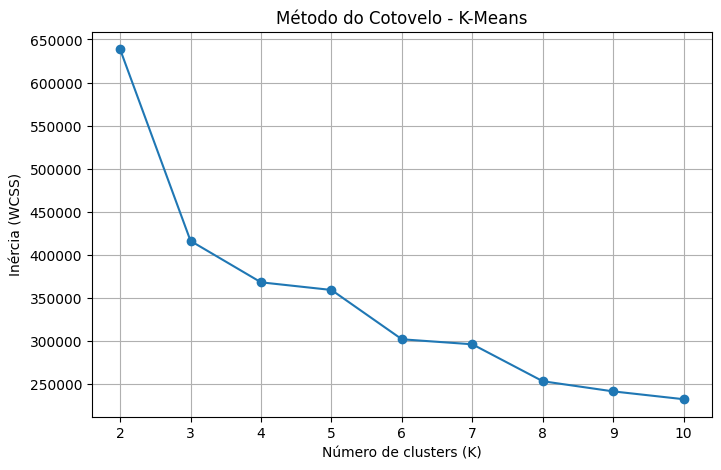

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Valores de K a serem testados
ks = range(2, 11)

inertias = []

for k in ks:

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init="auto"
    )

    model.fit(X_pca)

    inertias.append(model.inertia_)

# Plot do método do cotovelo
plt.figure(figsize=(8,5))

plt.plot(
    ks,
    inertias,
    marker='o'
)

plt.title("Método do Cotovelo - K-Means")
plt.xlabel("Número de clusters (K)")
plt.ylabel("Inércia (WCSS)")
plt.xticks(ks)
plt.grid(True)

plt.show()

In [ ]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init="auto"
)

labels_kmeans = kmeans.fit_predict(X_pca)

sil_kmeans = silhouette_score(
    X_pca,
    labels_kmeans
)

In [ ]:
hier = AgglomerativeClustering(
    n_clusters=3
)

labels_hier = hier.fit_predict(X_pca)

sil_hier = silhouette_score(
    X_pca,
    labels_hier
)

In [ ]:
db = DBSCAN(
    eps=0.5,
    min_samples=5
)

labels_db = db.fit_predict(X_pca)

In [ ]:
n_clusters_db = len(
    set(labels_db)
    -
    {-1}
)

In [ ]:
noise_ratio = np.mean(
    labels_db==-1
)

print("Ruído:",noise_ratio)

Ruído: 0.7463


In [ ]:
if n_clusters_db > 1:

    sil_db = silhouette_score(
        X_pca[labels_db!=-1],
        labels_db[labels_db!=-1]
    )

else:

    sil_db = np.nan

In [ ]:
tsne = TSNE(
    n_components=2,
    random_state=42
)

Y = tsne.fit_transform(X_pca)

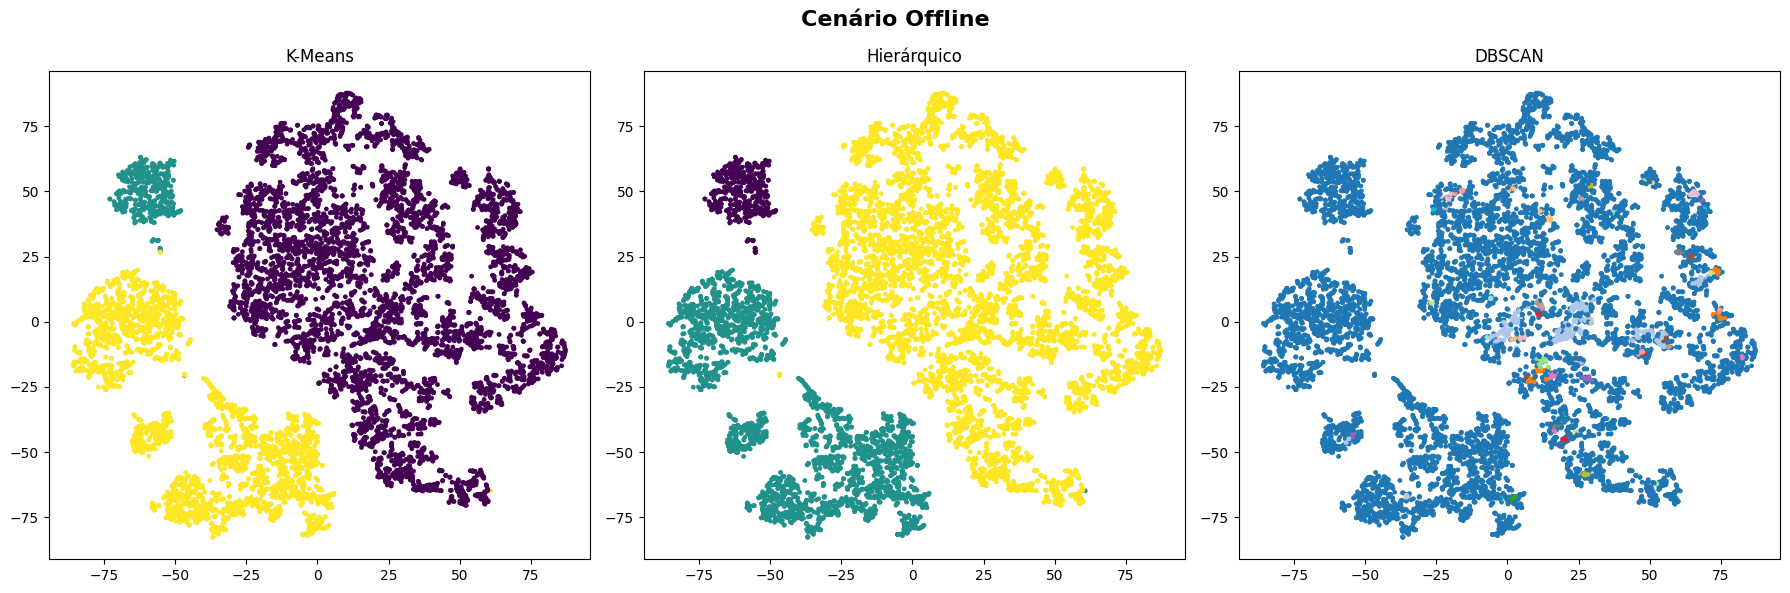

In [ ]:
fig,axes = plt.subplots(
    1,
    3,
    figsize=(18,6)
)

fig.suptitle(
    "Cenário Offline",
    fontsize=16,
    fontweight="bold"
)

axes[0].scatter(
    Y[:,0],
    Y[:,1],
    c=labels_kmeans,
    s=6
)

axes[0].set_title("K-Means")

axes[1].scatter(
    Y[:,0],
    Y[:,1],
    c=labels_hier,
    s=6
)

axes[1].set_title("Hierárquico")

axes[2].scatter(
    Y[:,0],
    Y[:,1],
    c=labels_db,
    s=6,
    cmap="tab20"
)

axes[2].set_title("DBSCAN")

plt.tight_layout()

plt.show()

In [ ]:
comparison = pd.DataFrame({

    "Algoritmo":[
        "K-Means",
        "Hierárquico",
        "DBSCAN"
    ],

    "Clusters":[
        len(np.unique(labels_kmeans)),
        len(np.unique(labels_hier)),
        n_clusters_db
    ],

    "Silhouette":[
        sil_kmeans,
        sil_hier,
        sil_db
    ],

    "Ruído (%)":[
        0,
        0,
        noise_ratio*100
    ]

})

comparison

,Algoritmo,Clusters,Silhouette,Ruído (%)
0,K-Means,3,0.552270,0.00
1,Hierárquico,3,0.551252,0.00
2,DBSCAN,56,-0.151824,74.63


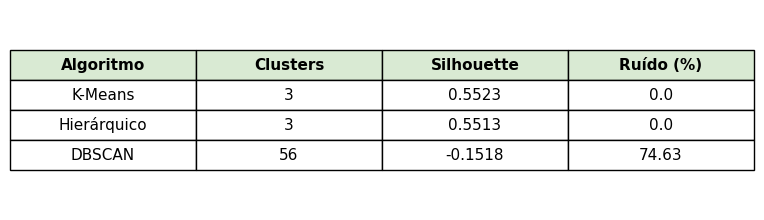

In [ ]:
import matplotlib.pyplot as plt

# ==========================
# Tabela dos resultados
# ==========================

fig, ax = plt.subplots(figsize=(8, 2.6))

ax.axis("off")

# Arredondamento dos valores
comparison_plot = comparison.copy()

comparison_plot["Silhouette"] = comparison_plot["Silhouette"].round(4)
comparison_plot["Ruído (%)"] = comparison_plot["Ruído (%)"].round(2)

table = ax.table(
    cellText=comparison_plot.values,
    colLabels=comparison_plot.columns,
    cellLoc='center',
    loc='center'
)

# Estilo
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.8)

# Cabeçalho
for (row, col), cell in table.get_celld().items():

    if row == 0:
        cell.set_text_props(weight='bold')
        cell.set_facecolor('#D9EAD3')   # verde claro
    else:
        cell.set_facecolor('white')

plt.title(
    "Cenário Offline: ",
    fontsize=12,
    weight='bold',
    pad=15
)

plt.savefig(
    "tabela_offline.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()